# Passive compliance — piano

How the hand's **passive task-space compliance** ($K_\mathrm{SWEEP}$) shapes the
*intensity* with which two fixed keys are struck. The MIDI **note-on velocity**
($0$–$127$) is the contact-force / loudness proxy used throughout the piano
literature (it maps monotonically onto musical dynamics $ppp\!\to\!fff$), and the
**piano roll** is the canonical way to display it. Only $K_\mathrm{SWEEP}$ varies
across conditions — every rotary (joint-space) spring is held fixed — so the
intensity differences below are a clean read-out of *passive* hand properties.

## Part 1 — Piano playing

Two keys are pressed every cycle by the **index** and **ring** fingers (the same
two notes throughout). Three conditions:

| condition | index $K$ | ring $K$ | meaning |
|-----------|-----------|----------|---------|
| uniform low  | $20$  | $20$  | both fingers compliant — gentle touch |
| uniform high | $100$ | $100$ | both fingers stiff — firm touch |
| heterogeneous| $100$ | $20$  | differentiated — one loud, one soft |

**Criterion.** A stiffer passive spring stores/delivers more energy into the key,
so we expect note-on velocity to rise monotonically with $K$, and the
heterogeneous condition to *split* the two notes apart in intensity.

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

sys.path.insert(0, os.path.join('../../'))      # repo root -> plot_config
sys.path.insert(0, 'HelperPianoMIDI')           # piano_config
from plot_config import draw_radar              # applies the shared Nature mplstyle
from piano_config import K_SWEEP, K_STIFF, K_SOFT, PRESS_DEPTH, PRESS_SPEED

# usetex needs a LaTeX install; fall back gracefully so the notebook always runs
import shutil
if shutil.which('latex') is None:
    plt.rcParams['text.usetex'] = False

COLORS   = plt.rcParams['axes.prop_cycle'].by_key()['color']   # NPG palette
C_INDEX  = COLORS[0]    # teal  — index finger
C_RING   = COLORS[1]    # red   — ring finger
C_LOW    = COLORS[2]    # green — low-K condition
C_HIGH   = COLORS[3]    # navy  — high-K condition
C_HET    = COLORS[4]    # salmon— heterogeneous
CMAP     = cm.plasma    # velocity colormap (matches the live midi_visualizer)

OUTPUT_DIR_PLAY = os.path.join('outputs', 'piano_playing_hand')
os.makedirs(OUTPUT_DIR_PLAY, exist_ok=True)

KLO, KHI = float(K_SWEEP[0]), float(K_SWEEP[1])

# software motor indices for the two playing fingers (MCP, PIP)
SLICE = {'index': slice(7, 9), 'ring': slice(11, 13)}

# Velocity -> musical dynamic levels (standard MIDI/DAW convention).
DYNAMICS = [(16,'ppp'),(33,'pp'),(49,'p'),(64,'mp'),(80,'mf'),(96,'f'),(112,'ff'),(127,'fff')]

def velocity_color(v):
    return CMAP(0.12 + 0.88 * np.clip(v, 0, 127) / 127)

def add_dynamics_axis(ax, side='right'):
    """Annotate a velocity axis with faint p/mf/f ... guide lines."""
    for v, name in DYNAMICS:
        ax.axhline(v, color='0.85', lw=0.6, ls=':', zorder=0)
        ax.text(1.005, v, name, transform=ax.get_yaxis_transform(),
                va='center', ha='left', fontsize=11, color='0.45')

In [2]:
# ----------------------------------------------------------------------------
# Data loading.  Real files take precedence; if a CSV is missing we synthesise
# a clearly-labelled DEMO dataset (same schema) so every figure still renders.
# ----------------------------------------------------------------------------
_S_COLS = ([f'q_{i}' for i in range(15)] +
           [f'qdot_{i}' for i in range(15)] +
           [f'tau_{i}' for i in range(15)])
FIELDS  = ['time_s','type','k_index','k_ring','cycle'] + _S_COLS + ['note','velocity']

NOTE_INDEX = 60   # C4 — key struck by the index finger   (override per keyboard)
NOTE_RING  = 64   # E4 — key struck by the ring finger
N_CYCLES   = 3
PRESS_PERIOD = 2 * PRESS_DEPTH / PRESS_SPEED

def _synth_block(k_index, k_ring, t0):
    """One DEMO condition: N_CYCLES press-lift strokes for both fingers."""
    rng = np.random.default_rng(int(k_index*7 + k_ring*13))
    rows = []
    for cyc in range(1, N_CYCLES + 1):
        t_start = t0 + (cyc - 1) * (PRESS_PERIOD + 0.6)
        ts = np.linspace(0, PRESS_PERIOD, 60)
        press = np.sin(np.pi * ts / PRESS_PERIOD)            # 0..1..0 press profile
        for tt, pr in zip(ts, press):
            row = {c: '' for c in FIELDS}
            row.update(time_s=f'{t_start+tt:.4f}', type='state',
                       k_index=k_index, k_ring=k_ring, cycle=cyc)
            tau = np.zeros(15)
            tau[SLICE['index']] = 0.0009 * k_index * pr * np.array([1.0, 0.6])
            tau[SLICE['ring']]  = 0.0009 * k_ring  * pr * np.array([1.0, 0.6])
            for i in range(15):
                row[f'tau_{i}'] = f'{tau[i]:.5f}'
                row[f'q_{i}']   = '0'; row[f'qdot_{i}'] = '0'
            rows.append(row)
        # note-on at the bottom of the press; velocity grows with that finger's K
        t_hit = t_start + PRESS_PERIOD/2
        for note, k in [(NOTE_INDEX, k_index), (NOTE_RING, k_ring)]:
            vel = int(np.clip(35 + 0.75*k + rng.normal(0, 3.5), 1, 127))
            row = {c: '' for c in FIELDS}
            row.update(time_s=f'{t_hit:.4f}', type='midi', k_index=k_index,
                       k_ring=k_ring, cycle=cyc, note=note, velocity=vel)
            rows.append(row)
    return rows

def _synth_file(pairs):
    rows, t = [], 0.0
    for ki, kr in pairs:
        rows += _synth_block(ki, kr, t)
        t = float(rows[-1]['time_s']) + 2.0
    return pd.DataFrame(rows, columns=FIELDS)

DEMO = False
def load_file(name, synth_pairs):
    global DEMO
    path = os.path.join(OUTPUT_DIR_PLAY, f'data_{name}.csv')
    if os.path.isfile(path):
        return pd.read_csv(path)
    DEMO = True
    return _synth_file(synth_pairs)

DATA = {
    'uniform':       load_file('uniform',       [(KLO, KLO), (KHI, KHI)]),
    'heterogeneous': load_file('heterogeneous', [(KHI, KLO)]),
}

# condition table — derived from the DATA so it always matches what was
# collected (config K_SWEEP is only a fallback for the synthetic demo).
def _pairs(df):
    return sorted({(float(a), float(b)) for a, b in zip(df['k_index'], df['k_ring'])})

_uni = sorted(_pairs(DATA['uniform']), key=lambda p: p[0])   # [(5,5),(50,50)]
_het = _pairs(DATA['heterogeneous'])                         # [(50,5)]

CONDITIONS = []
if _uni:
    lo = _uni[0]
    CONDITIONS.append(dict(key='low', file='uniform', ki=lo[0], kr=lo[1], color=C_LOW,
                           short=rf'$K={lo[0]:.0f}$', label=rf'uniform $K={lo[0]:.0f}$'))
if len(_uni) >= 2:
    hi = _uni[-1]
    CONDITIONS.append(dict(key='high', file='uniform', ki=hi[0], kr=hi[1], color=C_HIGH,
                           short=rf'$K={hi[0]:.0f}$', label=rf'uniform $K={hi[0]:.0f}$'))
for ki, kr in _het:
    CONDITIONS.append(dict(key='het', file='heterogeneous', ki=ki, kr=kr, color=C_HET,
                           short=r'hetero', label=rf'hetero $({ki:.0f},{kr:.0f})$'))

def cond_df(c):
    d = DATA[c['file']]
    return d[(d['k_index'] == c['ki']) & (d['k_ring'] == c['kr'])]

def midi_of(c):
    d = cond_df(c)
    m = d[d['type'] == 'midi'][['cycle','note','velocity']].copy()
    m[['note','velocity']] = m[['note','velocity']].astype(float)
    return m

def velocities(c, finger):
    note = NOTE_INDEX if finger == 'index' else NOTE_RING
    m = midi_of(c)
    return m[m['note'] == note]['velocity'].to_numpy()

# auto-detect notes if real data uses different ones than the defaults
_allnotes = sorted({int(n) for c in CONDITIONS for n in midi_of(c)['note'].tolist()})
if len(_allnotes) == 2 and set(_allnotes) != {NOTE_INDEX, NOTE_RING}:
    NOTE_INDEX, NOTE_RING = _allnotes
    print(f'Detected notes -> index={NOTE_INDEX}, ring={NOTE_RING}')

banner = ' DEMO (synthetic) data ' if DEMO else ' measured data '
print(f'Loaded{banner}|  notes: index={NOTE_INDEX}, ring={NOTE_RING}  |  '
      f'conditions: {[(c["key"], c["ki"], c["kr"]) for c in CONDITIONS]}')

# data-quality check: MIDI velocity must vary to carry intensity information
_allv = np.concatenate([midi_of(c)['velocity'].to_numpy() for c in CONDITIONS]
                       ) if CONDITIONS else np.array([])
if _allv.size and np.ptp(_allv) == 0:
    print(f'\n  WARNING: every note-on velocity = {int(_allv[0])} (no spread).\n'
          '  The MIDI keyboard is not reporting touch-sensitive velocity, so the\n'
          '  intensity figures will be flat. Use a velocity-sensitive keyboard to\n'
          '  capture passive-compliance differences in touch.')

Detected notes -> index=60, ring=65
Loaded measured data |  notes: index=60, ring=65  |  conditions: [('low', 5.0, 5.0), ('high', 50.0, 50.0), ('het', 50.0, 5.0)]

  The MIDI keyboard is not reporting touch-sensitive velocity, so the
  intensity figures will be flat. Use a velocity-sensitive keyboard to
  capture passive-compliance differences in touch.


### Figure 1 — Piano roll (intensity over time)

The literature-standard MIDI view: time on $x$, note on $y$, **colour = velocity**
(intensity). One lane per condition makes the louder/softer touch immediately
legible, and the heterogeneous lane shows the two notes drifting apart in colour.

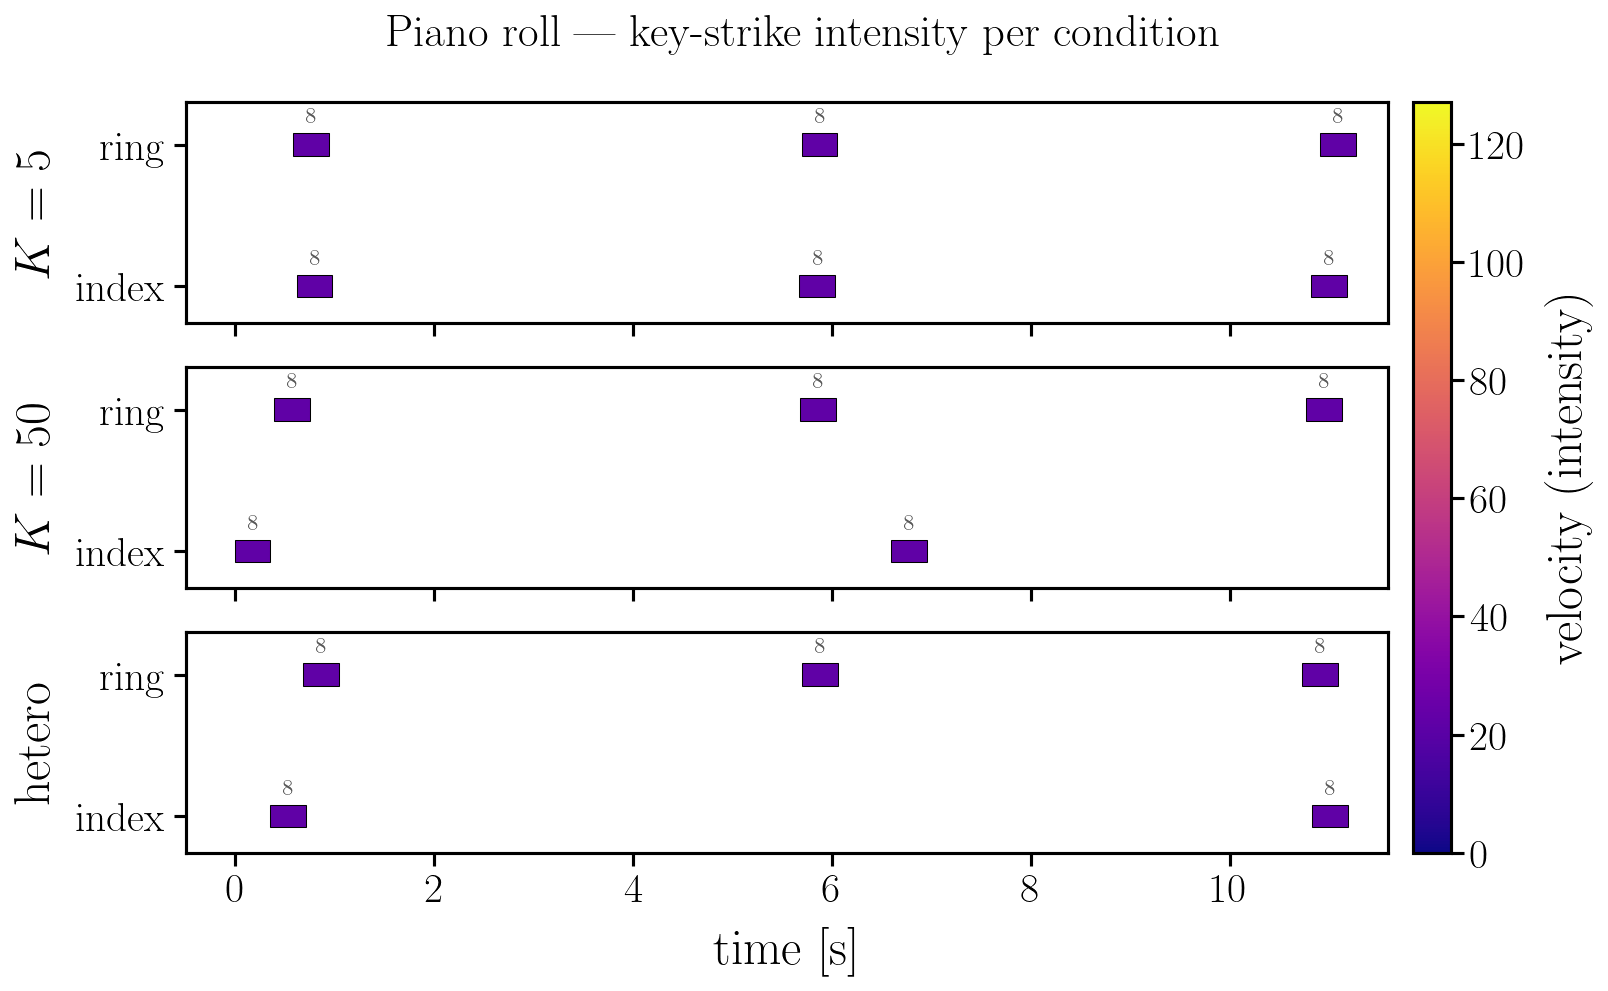

In [3]:
note_lo, note_hi = min(NOTE_INDEX, NOTE_RING), max(NOTE_INDEX, NOTE_RING)

# first pass: relative event times per condition + global time span
rel, tmax = {}, 0.0
for c in CONDITIONS:
    full = cond_df(c)
    t0   = full['time_s'].astype(float).min()
    fm   = full[full['type'] == 'midi'].copy()
    fm['t'] = fm['time_s'].astype(float) - t0
    rel[c['key']] = fm
    if len(fm): tmax = max(tmax, float(fm['t'].max()))

fig, axes = plt.subplots(len(CONDITIONS), 1, figsize=(11, 6.5), sharex=True)
for ax, c in zip(axes, CONDITIONS):
    for _, ev in rel[c['key']].iterrows():
        t, n, v = float(ev['t']), float(ev['note']), float(ev['velocity'])
        ax.add_patch(plt.Rectangle((t-0.18, n-0.4), 0.36, 0.8,
                     facecolor=velocity_color(v), edgecolor='k', lw=0.5, zorder=3))
        ax.text(t, n+0.62, f'{int(v)}', ha='center', va='bottom', fontsize=11,
                color='0.35', clip_on=True)
    ax.set_yticks([NOTE_INDEX, NOTE_RING])
    ax.set_yticklabels([r'index', r'ring'])
    ax.set_ylim(note_lo-1.3, note_hi+1.5)
    ax.set_xlim(-0.5, tmax + 0.5)          # explicit — keeps labels in-frame
    ax.set_ylabel(c['short'])
    ax.grid(False)

axes[-1].set_xlabel(r'time [s]')
sm = cm.ScalarMappable(cmap=CMAP, norm=Normalize(0, 127)); sm.set_array([])
cbar = fig.colorbar(sm, ax=list(axes), fraction=0.04, pad=0.02)
cbar.set_label(r'velocity (intensity)')
fig.suptitle('Piano roll — key-strike intensity per condition', y=0.97)
if DEMO: fig.text(0.5, 0.5, 'DEMO', fontsize=90, color='0.92',
                  ha='center', va='center', rotation=30, zorder=0)
fig.savefig(os.path.join(OUTPUT_DIR_PLAY, 'fig1_piano_roll.pdf'))
plt.show()

### Figure 2 — Intensity per note across conditions

Mean note-on velocity for each finger in each condition (bars = mean over the
$N_\mathrm{cycles}$ strokes, error bars = std, dots = individual strokes). This is
the headline read-out: how passive compliance sets touch intensity, and how the
heterogeneous condition separates the two fingers.

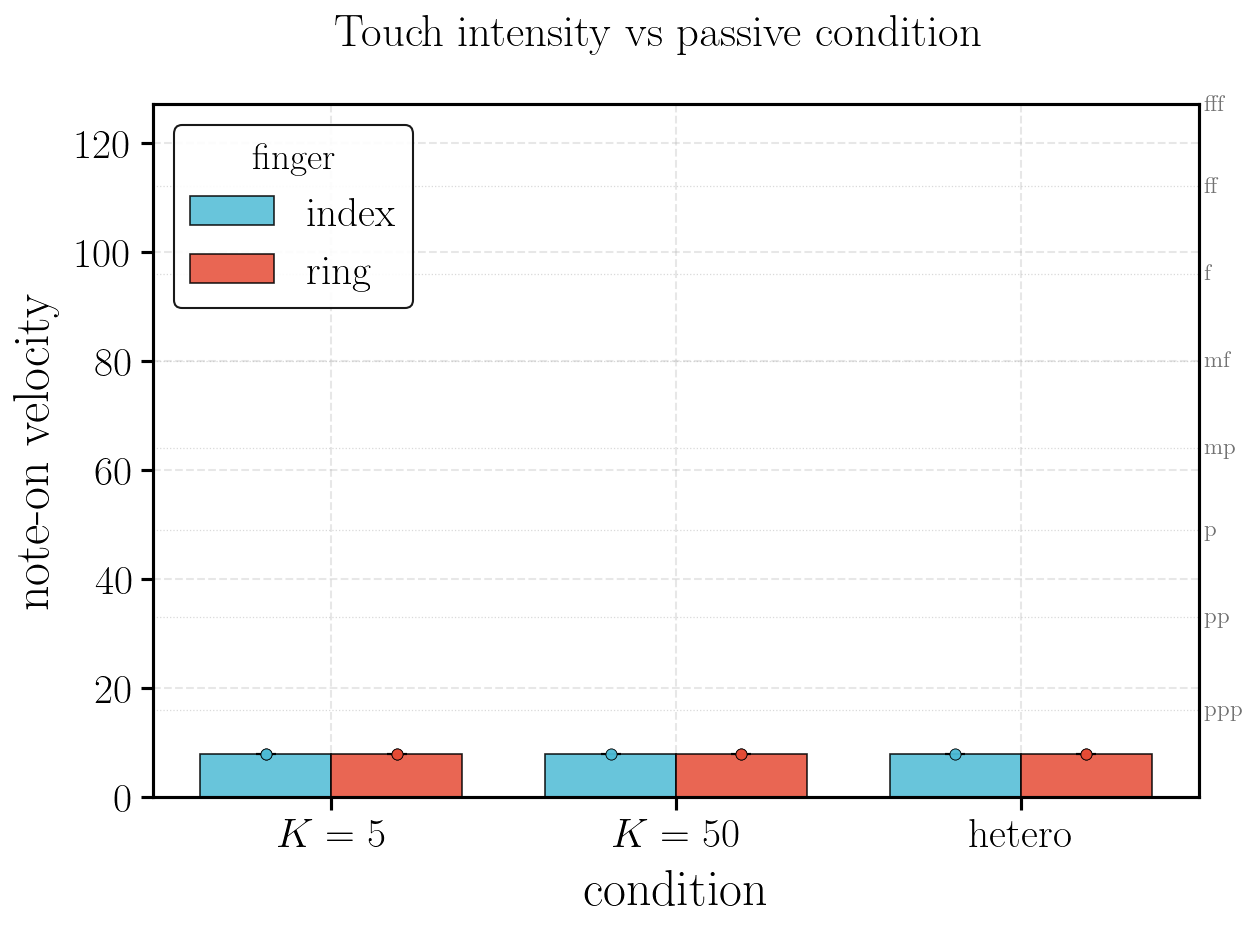

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(CONDITIONS)); w = 0.38
for j, (finger, col) in enumerate([('index', C_INDEX), ('ring', C_RING)]):
    means, stds = [], []
    for i, c in enumerate(CONDITIONS):
        v = velocities(c, finger)
        means.append(np.mean(v) if len(v) else np.nan)
        stds.append(np.std(v)  if len(v) else 0.0)
        ax.scatter(np.full_like(v, x[i] + (j-0.5)*w), v, s=28, color=col,
                   edgecolor='k', linewidth=0.4, alpha=0.8, zorder=4)
    ax.bar(x + (j-0.5)*w, means, w, yerr=stds, capsize=5, color=col,
           edgecolor='k', linewidth=0.8, alpha=0.85, zorder=2,
           label=rf'{finger}')
ax.set_xticks(x); ax.set_xticklabels([c['short'] for c in CONDITIONS])
ax.set_ylabel(r'note-on velocity'); ax.set_ylim(0, 127)
ax.set_xlabel(r'condition')
add_dynamics_axis(ax)
ax.legend(title=r'finger', loc='upper left')
fig.suptitle('Touch intensity vs passive condition')
if DEMO: fig.text(0.5, 0.5, 'DEMO', fontsize=90, color='0.92',
                  ha='center', va='center', rotation=30, zorder=0)
fig.savefig(os.path.join(OUTPUT_DIR_PLAY, 'fig2_intensity_per_note.pdf'))
plt.show()

### Figure 3 — Intensity vs stiffness

Velocity as a function of the finger's own $K$. The uniform sweep gives each
finger at $K=20$ and $K=100$; the heterogeneous points (open markers) are
overlaid to show the per-finger response is set by *that finger's* compliance,
independent of its neighbour.

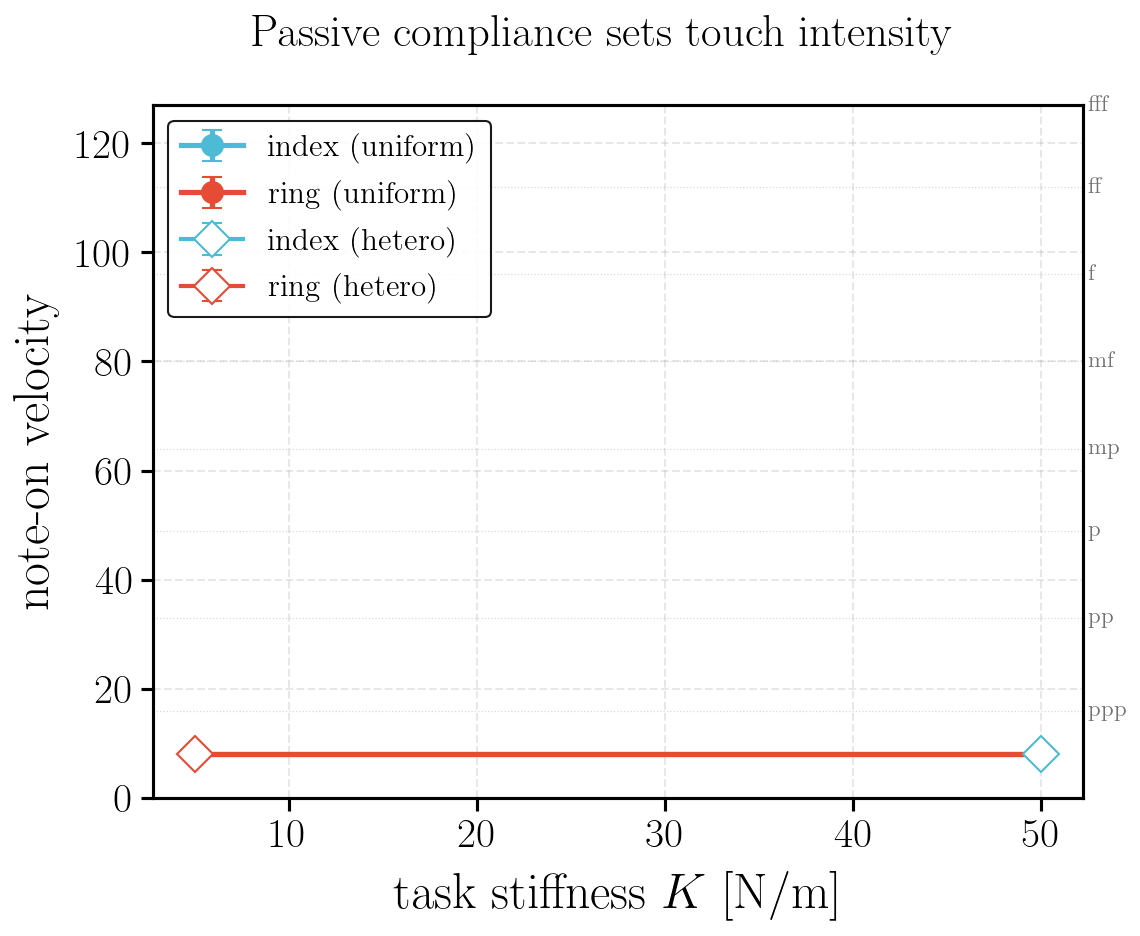

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
# uniform sweep: each finger at KLO and KHI
for finger, col in [('index', C_INDEX), ('ring', C_RING)]:
    ks, mu, sd = [], [], []
    for c in CONDITIONS:
        if c['key'] in ('low', 'high'):
            v = velocities(c, finger)
            ks.append(c['ki']); mu.append(np.mean(v)); sd.append(np.std(v))
    order = np.argsort(ks)
    ks = np.array(ks)[order]; mu = np.array(mu)[order]; sd = np.array(sd)[order]
    ax.errorbar(ks, mu, yerr=sd, marker='o', color=col, capsize=5,
                lw=2.5, label=rf'{finger} (uniform)')
# heterogeneous overlay
het = next((c for c in CONDITIONS if c['key'] == 'het'), None)
if het is not None:
    for finger, col, k in [('index', C_INDEX, het['ki']), ('ring', C_RING, het['kr'])]:
        v = velocities(het, finger)
        if len(v):
            ax.errorbar([k], [np.mean(v)], yerr=[np.std(v)], marker='D', ms=12,
                        mfc='white', mec=col, ecolor=col, capsize=5, lw=2,
                        label=rf'{finger} (hetero)')
ax.set_xlabel(r'task stiffness $K$ [N/m]')
ax.set_ylabel(r'note-on velocity'); ax.set_ylim(0, 127)
add_dynamics_axis(ax)
ax.legend(loc='upper left', fontsize='small')
fig.suptitle('Passive compliance sets touch intensity')
if DEMO: fig.text(0.5, 0.5, 'DEMO', fontsize=90, color='0.92',
                  ha='center', va='center', rotation=30, zorder=0)
fig.savefig(os.path.join(OUTPUT_DIR_PLAY, 'fig3_intensity_vs_K.pdf'))
plt.show()

### Figure 4 — Stroke-to-stroke consistency

Velocity of every individual stroke, cycle by cycle. Tight clustering means a
*repeatable* passive response — a desirable property for a compliant hand.

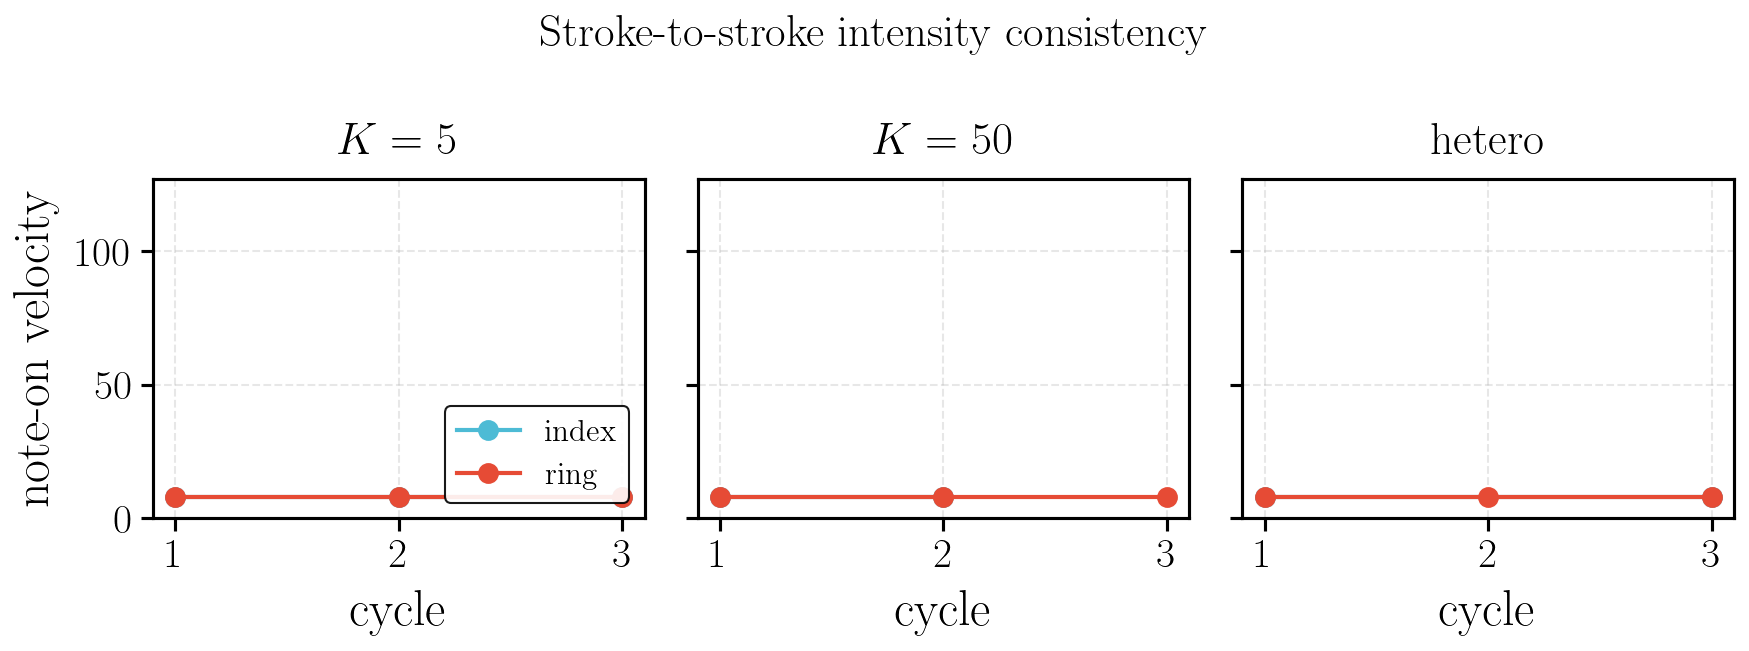

In [6]:
fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(12, 4.5), sharey=True)
for ax, c in zip(axes, CONDITIONS):
    for finger, col in [('index', C_INDEX), ('ring', C_RING)]:
        m = midi_of(c)
        note = NOTE_INDEX if finger == 'index' else NOTE_RING
        sub = m[m['note'] == note]
        ax.plot(sub['cycle'], sub['velocity'], 'o-', color=col, ms=9,
                lw=2, label=rf'{finger}')
    ax.set_title(c['short']); ax.set_xlabel(r'cycle')
    ax.set_xticks(range(1, N_CYCLES + 1)); ax.set_ylim(0, 127)
axes[0].set_ylabel(r'note-on velocity')
axes[0].legend(loc='lower right', fontsize='small')
fig.suptitle('Stroke-to-stroke intensity consistency')
if DEMO: fig.text(0.5, 0.5, 'DEMO', fontsize=80, color='0.93',
                  ha='center', va='center', rotation=20, zorder=0)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR_PLAY, 'fig4_consistency.pdf'))
plt.show()

### Figure 5 — Passive-property fingerprint

A compact summary of each condition on four interpretable axes
(all normalised per axis):

- **Loudness** — mean velocity over both notes.
- **Differentiation** — $|v_\mathrm{index}-v_\mathrm{ring}|$ (the heterogeneous signature).
- **Consistency** — $1-\overline{\mathrm{CV}}$ of velocity across strokes.
- **Effort** — peak joint torque at the playing fingers during the press.

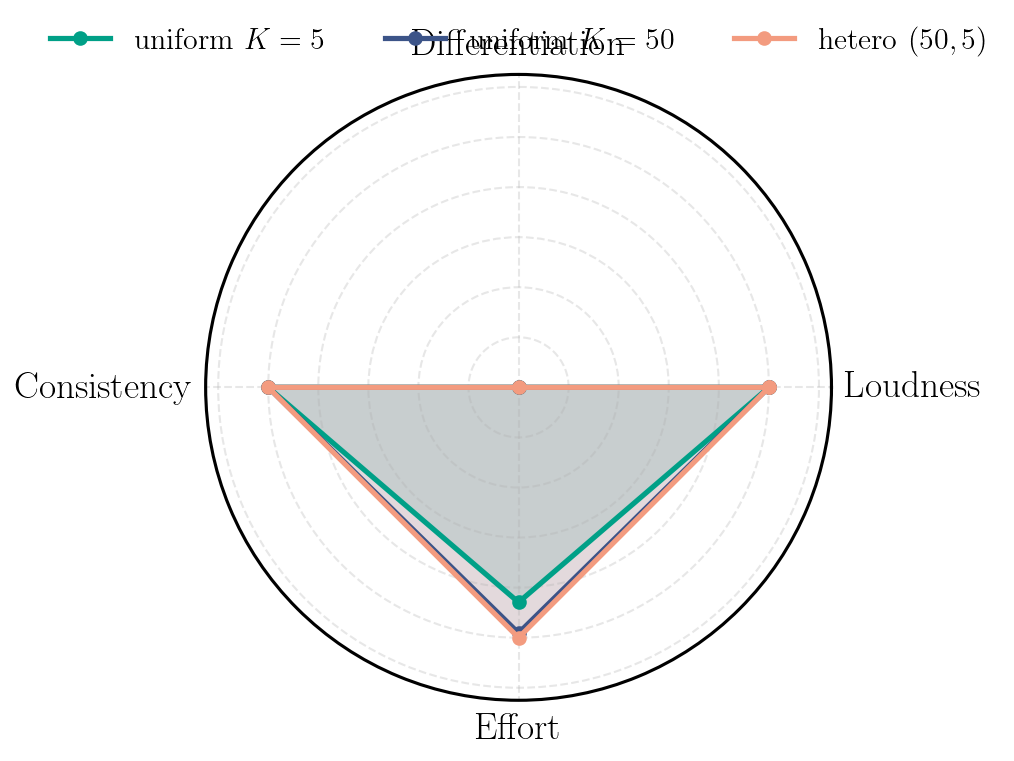

In [7]:
def cond_metrics(c):
    vi, vr = velocities(c, 'index'), velocities(c, 'ring')
    loud = np.nanmean(np.concatenate([vi, vr])) if len(vi)+len(vr) else 0.0
    diff = abs(np.mean(vi) - np.mean(vr)) if len(vi) and len(vr) else 0.0
    cvs = []
    for v in (vi, vr):
        if len(v) and np.mean(v) > 0: cvs.append(np.std(v)/np.mean(v))
    cons = max(0.0, 1.0 - (np.mean(cvs) if cvs else 0.0))
    d = cond_df(c); st = d[d['type'] == 'state']
    eff = 0.0
    if len(st):
        cols = [f'tau_{i}' for i in list(range(7,9)) + list(range(11,13))]
        tau = st[cols].astype(float).to_numpy()
        eff = float(np.max(np.linalg.norm(tau, axis=1)))
    return [loud, diff, cons, eff]

spokes = ['Loudness', 'Differentiation', 'Consistency', 'Effort']
traces = [dict(label=c['label'], color=c['color'], values=cond_metrics(c))
          for c in CONDITIONS]
fig, ax = draw_radar(spokes, traces,
                     save_path=os.path.join(OUTPUT_DIR_PLAY, 'fig5_fingerprint.pdf'))

## Part 2 — Glissando

*(to be written — same philosophy: the UR5 slides along the keys while the index
and ring fingers are held at the press pose, and we read the resulting stream of
note-on velocities as the passive-compliance fingerprint of a sweep.)*